# Perceptrón AND con visualizaciones interactivas (paso a paso)

En este Notebook implementamos un **perceptrón** muy simple para aprender la compuerta lógica AND,
pero ahora con:

1. Entrenamiento paso a paso.
2. Gráfica de la evolución del error (loss).
3. Gráfica de la evolución de los pesos y el bias.
4. Visualización de la frontera de decisión a lo largo del entrenamiento.
5. Versión interactiva con un *slider* para ver la frontera de decisión en distintas épocas.


## 1. Definimos el problema: compuerta AND

Tabla de verdad de AND:

- Entrada (0, 0) → Salida esperada: 0
- Entrada (0, 1) → Salida esperada: 0
- Entrada (1, 0) → Salida esperada: 0
- Entrada (1, 1) → Salida esperada: 1

Interpretación:

- La salida será 1 **solo si** las dos entradas son 1.

Usaremos estas 4 combinaciones como nuestro conjunto de entrenamiento.


In [1]:
# 2. Importamos las librerías necesarias
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider


In [2]:
# 3. Creamos los datos de entrada (X) y las salidas esperadas (y)

X = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y = np.array([0, 0, 0, 1], dtype=float)

print("Entradas X:", X)
print("Salidas esperadas y:", y)


Entradas X: [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
Salidas esperadas y: [0. 0. 0. 1.]


Interpretación:

- `X` es nuestra **capa de entrada** con 2 características (x1 y x2).
- `y` es la **capa de salida** deseada (solo un valor por ejemplo).


In [3]:
# 4. Definimos la función de activación (sigmoide) y su derivada

def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def sigmoid_derivative(a):
    return a * (1 - a)

z_ejemplo = 0.5
a_ejemplo = sigmoid(z_ejemplo)
print("Ejemplo sigmoide:")
print("z =", z_ejemplo)
print("sigmoid(z) =", a_ejemplo)


Ejemplo sigmoide:
z = 0.5
sigmoid(z) = 0.6224593312018546


Interpretación de la fórmula sigmoide:

- Recibe un número real z y lo transforma en algo entre 0 y 1.
- Si z es muy positivo, la salida se acerca a 1.
- Si z es muy negativo, la salida se acerca a 0.

Ejemplo numérico:

- Si z = 0.5, entonces la salida es aproximadamente 0.62, es decir, podemos interpretar esto como un 62% de probabilidad de ser clase 1.


In [4]:
# 5. Inicializamos los pesos y el sesgo (bias)

np.random.seed(42)

W = np.random.randn(2)
b = np.random.randn()

print("Pesos iniciales W:", W)
print("Bias inicial b:", b)


Pesos iniciales W: [ 0.49671415 -0.1382643 ]
Bias inicial b: 0.6476885381006925


Interpretación:

- W guarda la importancia de cada entrada.
- b permite desplazar la función de activación hacia arriba o abajo.
- Empezamos con valores aleatorios para que el perceptrón luego los vaya corrigiendo durante el entrenamiento.


In [5]:
# 6. Definimos hiperparámetros de entrenamiento

learning_rate = 0.1
n_epochs = 2000

print("Tasa de aprendizaje:", learning_rate)
print("Número de épocas:", n_epochs)


Tasa de aprendizaje: 0.1
Número de épocas: 2000


Interpretación:

- Tasa de aprendizaje: qué tan grandes son los pasos al modificar los pesos.
- Épocas: cuántas veces pasamos por todos los ejemplos de entrenamiento.

Si la tasa de aprendizaje es muy grande, podemos saltarnos la solución.
Si es muy pequeña, el entrenamiento puede ser demasiado lento.


In [6]:
# 7. Entrenamos el perceptrón, guardando la historia de loss, pesos y bias

loss_history = []
W_history = []
b_history = []

for epoch in range(n_epochs):
    W_history.append(W.copy())
    b_history.append(b)

    z = np.dot(X, W) + b
    a = sigmoid(z)

    loss = np.mean((y - a) ** 2)
    loss_history.append(loss)

    dL_da = 2 * (a - y) / len(y)
    da_dz = sigmoid_derivative(a)
    dL_dz = dL_da * da_dz

    dL_dW = np.dot(X.T, dL_dz)
    dL_db = np.sum(dL_dz)

    W -= learning_rate * dL_dW
    b -= learning_rate * dL_db

    if (epoch + 1) % 400 == 0:
        print(f"Época {epoch+1}/{n_epochs} - Loss: {loss:.4f}")

W_history = np.array(W_history)

print("Pesos finales W:", W)
print("Bias final b:", b)


Época 400/2000 - Loss: 0.1114
Época 800/2000 - Loss: 0.0717
Época 1200/2000 - Loss: 0.0524
Época 1600/2000 - Loss: 0.0407
Época 2000/2000 - Loss: 0.0330
Pesos finales W: [2.59416102 2.59253572]
Bias final b: -4.0163998086815775


Interpretación del entrenamiento:

1. Forward pass: calculamos z = X·W + b y luego a = sigmoid(z).
2. Loss (MSE): medimos qué tan lejos estamos de y.
3. Backpropagation: usamos la regla de la cadena para obtener cómo cambia el error respecto a W y b.
4. Actualización: movemos W y b en la dirección que reduce el error.

Además, vamos guardando en loss_history, W_history y b_history cómo evoluciona todo durante el entrenamiento.


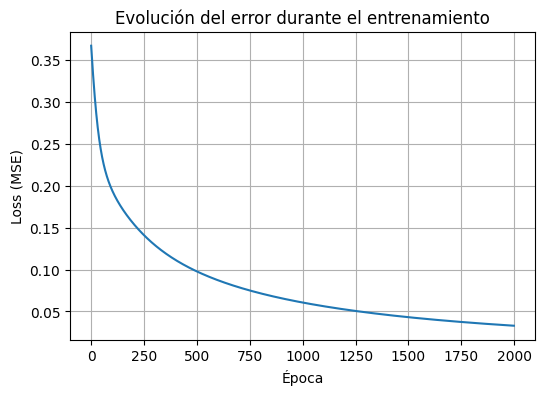

In [7]:
# 8. Graficamos la evolución del loss durante el entrenamiento

plt.figure(figsize=(6,4))
plt.plot(loss_history)
plt.xlabel('Época')
plt.ylabel('Loss (MSE)')
plt.title('Evolución del error durante el entrenamiento')
plt.grid(True)
plt.show()


Interpretación del gráfico de loss:

- El eje X son las épocas.
- El eje Y es el error.
- Si la curva baja, significa que el perceptrón está aprendiendo a aproximar la compuerta AND.


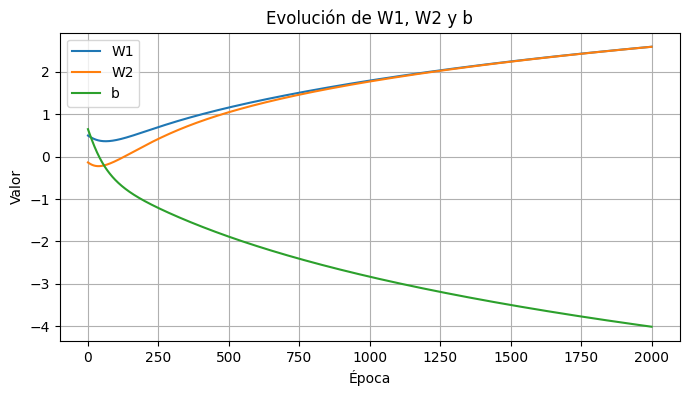

In [8]:
# 9. Graficamos la evolución de los pesos W1, W2 y del bias b

plt.figure(figsize=(8,4))
plt.plot(W_history[:, 0], label="W1")
plt.plot(W_history[:, 1], label="W2")
plt.plot(b_history, label="b")
plt.xlabel('Época')
plt.ylabel('Valor')
plt.title('Evolución de W1, W2 y b')
plt.legend()
plt.grid(True)
plt.show()


Interpretación de la evolución de parámetros:

- Cada curva muestra cómo cambia uno de los parámetros (W1, W2, b) a lo largo de las épocas.
- Al estabilizarse, indica que el perceptrón ya no está cambiando mucho sus parámetros (se acerca a una solución).


In [9]:
# 10. Definimos una función para dibujar la frontera de decisión

def plot_decision_boundary(W_plot, b_plot, epoch):
    plt.figure(figsize=(4,4))

    for i, x in enumerate(X):
        if y[i] == 0:
            plt.scatter(x[0], x[1], color="red", label="Clase 0" if i == 0 else "")
        else:
            plt.scatter(x[0], x[1], color="blue", label="Clase 1" if i == 3 else "")

    x1_vals = np.linspace(-0.2, 1.2, 100)
    if W_plot[1] != 0:
        x2_vals = -(W_plot[0] * x1_vals + b_plot) / W_plot[1]
        plt.plot(x1_vals, x2_vals, color="green", label="Frontera de decisión")

    plt.xlim(-0.2, 1.2)
    plt.ylim(-0.2, 1.2)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(f"Frontera de decisión (época {epoch})")
    plt.legend()
    plt.grid(True)
    plt.show()


Interpretación de la frontera de decisión:

- Los puntos rojos y azules son nuestros datos AND.
- La línea verde es la frontera donde el perceptrón decide si la salida es 0 o 1.
- A medida que entrenamos, esa recta se mueve hasta separar correctamente las clases.


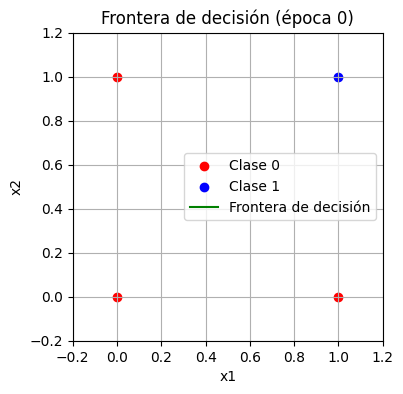

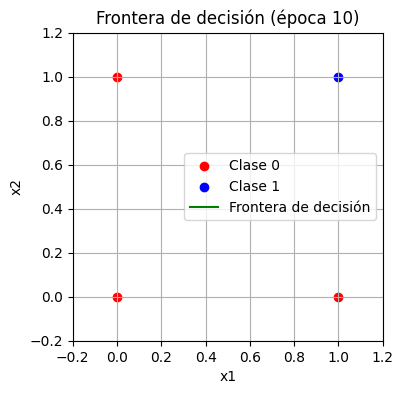

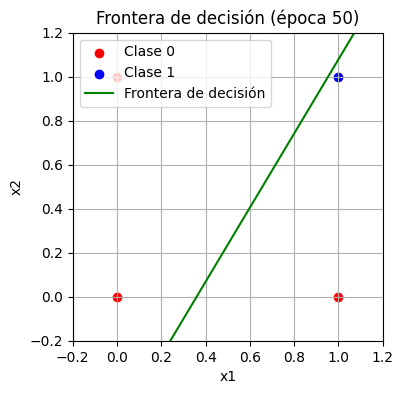

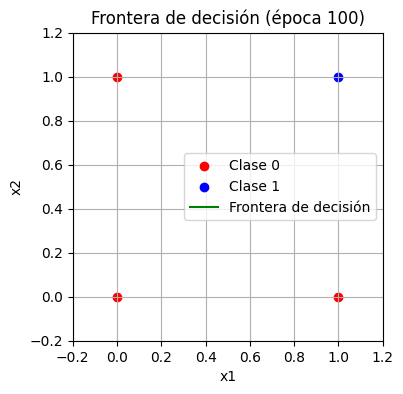

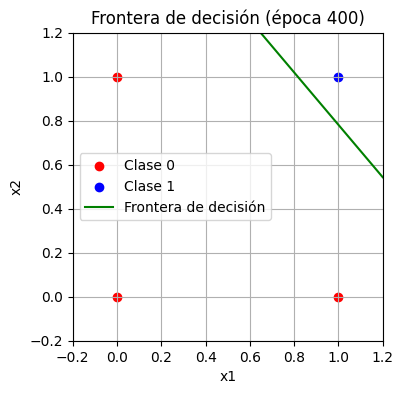

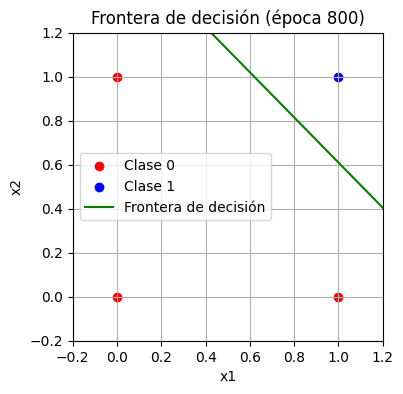

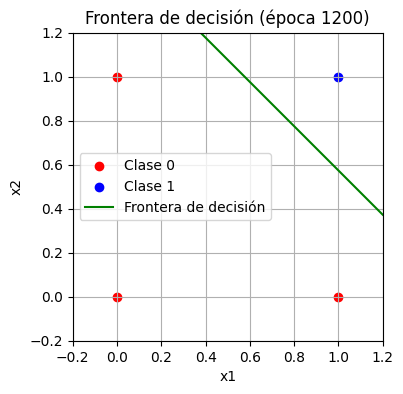

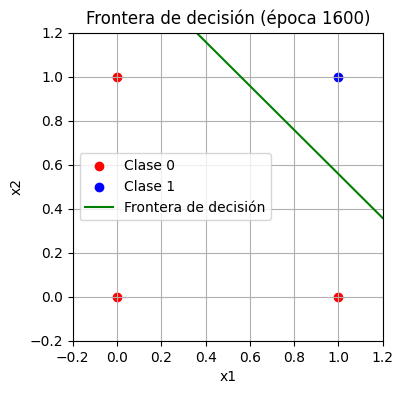

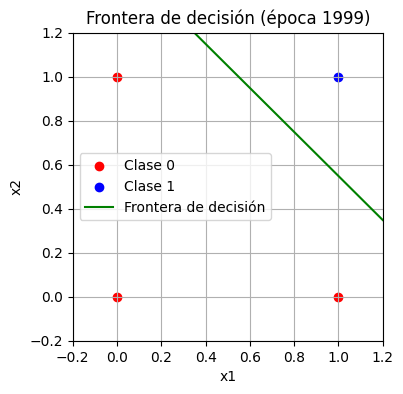

In [10]:
# 11. Visualización "animada": mostramos la frontera cada cierto número de épocas

epocas_mostrar = [0, 10, 50, 100, 400, 800, 1200, 1600, 1999]

for ep in epocas_mostrar:
    if ep < len(W_history):
        W_ep = W_history[ep]
        b_ep = b_history[ep]
        plot_decision_boundary(W_ep, b_ep, ep)


Interpretación de esta "animación":

- No es un GIF, pero al ejecutar la celda verás varias figuras, una por época seleccionada.
- Puedes ir mirando cómo la recta verde se ajusta progresivamente.


In [11]:
# 12. Versión interactiva con slider

@interact(epoch=IntSlider(min=0, max=n_epochs-1, step=10, value=0))
def interactive_decision_boundary(epoch):
    W_ep = W_history[epoch]
    b_ep = b_history[epoch]
    plot_decision_boundary(W_ep, b_ep, epoch)


interactive(children=(IntSlider(value=0, description='epoch', max=1999, step=10), Output()), _dom_classes=('wi…

Cómo usar la versión interactiva:

- Mueve el slider de epoch.
- En cada posición, se dibuja la frontera de decisión con los parámetros aprendidos en esa época.
- Esto te permite ver cómo el perceptrón va aprendiendo con el tiempo.


In [12]:
# 13. Probamos el perceptrón ya entrenado en las 4 combinaciones AND

z = np.dot(X, W) + b
a = sigmoid(z)

predicciones = (a >= 0.5).astype(int)

print("Entradas:", X)
print("Probabilidades predichas:", a)
print("Predicciones finales (0/1):", predicciones)
print("Etiquetas reales:", y.astype(int))


Entradas: [[0. 0.]
 [0. 1.]
 [1. 0.]
 [1. 1.]]
Probabilidades predichas: [0.01769882 0.19405653 0.19431085 0.76319868]
Predicciones finales (0/1): [0 0 0 1]
Etiquetas reales: [0 0 0 1]


Interpretación de las predicciones finales:

- a son las salidas entre 0 y 1 (probabilidades de ser clase 1).
- predicciones aplica un umbral de 0.5 para decidir 0 o 1.
- Si todo salió bien, verás que el modelo predice 1 solo cuando la entrada es [1, 1].
